# 1 · Data and exploratory analysis
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/twillixa/NBA-Analysis/blob/main/notebooks/01_data_and_eda.ipynb)

Twenty-one regular seasons (2004-05 to 2024-25) of [Basketball-Reference](https://www.basketball-reference.com)
player per-game stats and team standings. A season is named by the year it **ends** (2025 = 2024-25).

The questions from the report:
1. Which team statistics move with winning?
2. Are three-pointers worth more than twos?
3. Does offense or defense matter more?
4. How much does award-winning talent help?

This notebook uses the **corrected** cleaning (`CORRECTED` options, see notebook 3's audit log) and prints the
report's original value next to each result so every difference is visible.

In [1]:
import sys, os
if "google.colab" in sys.modules:  # running on Colab: fetch the repo first
    !git clone -q https://github.com/twillixa/NBA-Analysis
    %cd NBA-Analysis/notebooks
sys.path.insert(0, os.path.abspath("../src"))

import warnings
warnings.simplefilter("ignore", FutureWarning)
warnings.filterwarnings("ignore", message=".*encountered in matmul")  # spurious on macOS Accelerate
import pandas as pd
from nba import plots
from nba.data import build_datasets, CORRECTED
plots.use_style()
pd.set_option("display.precision", 3)
from nba import eda

## Load and clean
`build_datasets()` (in `src/nba/data.py`) does what the report's section 2 describes:
- maps every franchise to its current code (NJN → BRK, SEA → OKC, CHA → CHO, …)
- turns the `Awards` string (`"MVP-1DPOY-10ASNBA1"`) into dummies and identifies the actual MVP/DPOY winner
- adds **previous-season** award flags (`MVP-1`, `ALL-NBA-1`, …), the only award information a forecaster has before the season
- parses `"64-18"` records into W, L, W%

With `CORRECTED` it also drops traded players' multi-team total rows and the "League Average" row, uses the
standard True Shooting formula, and looks lagged awards up by season.

In [2]:
players, standings = build_datasets(**CORRECTED)
report_players, _ = build_datasets()  # the report's original cleaning, for comparison
print(f"{players.groupby(['Player', 'Season']).ngroups:,} player-seasons "
      f"({len(players):,} team stints) · {len(standings)} team-seasons · "
      f"{standings.Season.min()}-{standings.Season.max()}")
players[["Player", "Team", "Season", "PTS", "TRB", "AST", "TS%", "Awards", "ALL-NBA-1"]].head()

10,473 player-seasons (11,931 team stints) · 630 team-seasons · 2005-2025


,Player,Team,Season,PTS,TRB,AST,TS%,Awards,ALL-NBA-1
0,Allen Iverson,PHI,2005,30.7,4.0,7.9,0.533,MVP-5DPOY-11ASNBA1,0
1,Kobe Bryant,LAL,2005,27.6,5.9,6.0,0.562,ASNBA3,0
2,LeBron James,CLE,2005,27.2,7.4,7.2,0.552,MVP-6ASNBA2,0
3,Dirk Nowitzki,DAL,2005,26.1,9.7,3.1,0.580,MVP-3ASNBA1,0
4,Amar'e Stoudemire,PHO,2005,26.0,8.9,1.6,0.617,MVP-9ASNBA2,0


In [3]:
standings[["Season", "Team", "W", "L", "W%", "HW%", "RW%"]].describe().round(3)

,Season,W,L,W%,HW%,RW%
count,630.00,630.000,630.000,630.000,630.000,630.000
mean,2015.00,40.108,40.108,0.500,0.581,0.418
std,6.06,12.365,12.273,0.151,0.170,0.154
min,2005.00,7.000,9.000,0.106,0.121,0.073
25%,2010.00,32.000,31.000,0.390,0.463,0.293
50%,2015.00,41.000,39.000,0.512,0.585,0.415
75%,2020.00,49.000,49.000,0.610,0.707,0.537
max,2025.00,73.000,72.000,0.890,0.976,0.829


## 1 · Which statistics move with winning?
Team averages of player stats, correlated with team win %. Award flags are from the **previous** season, so they are known before tip-off.

,corrected,report
PTS,-0.19,-0.19
AST,-0.18,-0.18
STL,-0.22,-0.22
BLK,0.05,0.05
TRB,-0.24,-0.24
TS%,0.26,0.25
PF,-0.35,-0.35
TOV,-0.45,-0.45
FT,-0.20,-0.20
MVP-1,0.48,0.48


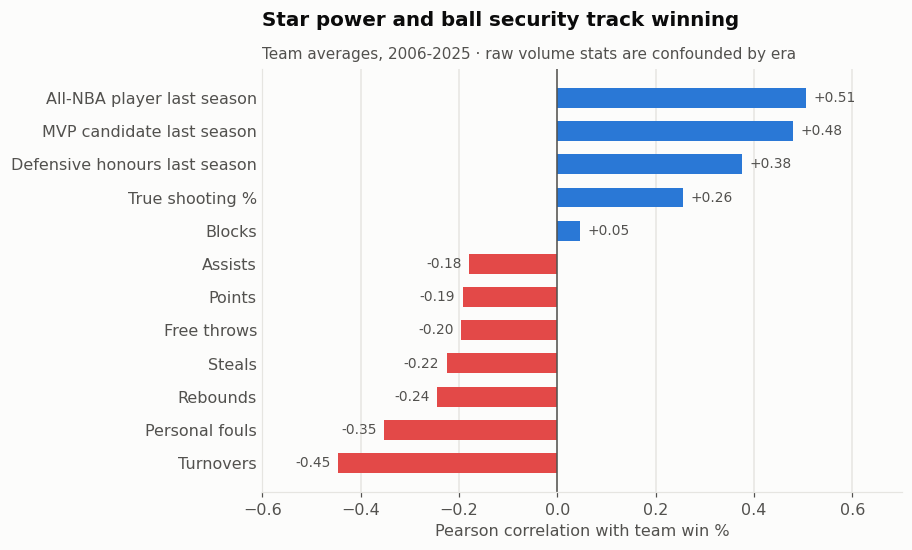

In [4]:
corr = eda.team_correlations(players, standings)
fig = plots.win_correlations(corr["W%"]); plots.save(fig, "win_correlations")
pd.DataFrame({"corrected": corr["W%"],
              "report": eda.team_correlations(report_players, standings)["W%"]}).drop("W%").round(2)

Raw volume (points, assists, rebounds) correlates *negatively*: scoring rose league-wide over these 20 years,
so 100 points meant something different in 2005 than in 2025. Turnovers (−0.45) and fouls (−0.35), which both give the
ball away, and prior-season All-NBA / MVP players are the clearest signals.

## 2 · Are three-pointers worth more than twos?

3PA per team: 23 → 63 (+175%; report: +171%)
3PA share of shots (%): {2005: 19, 2010: 23, 2015: 29, 2020: 40, 2025: 43}


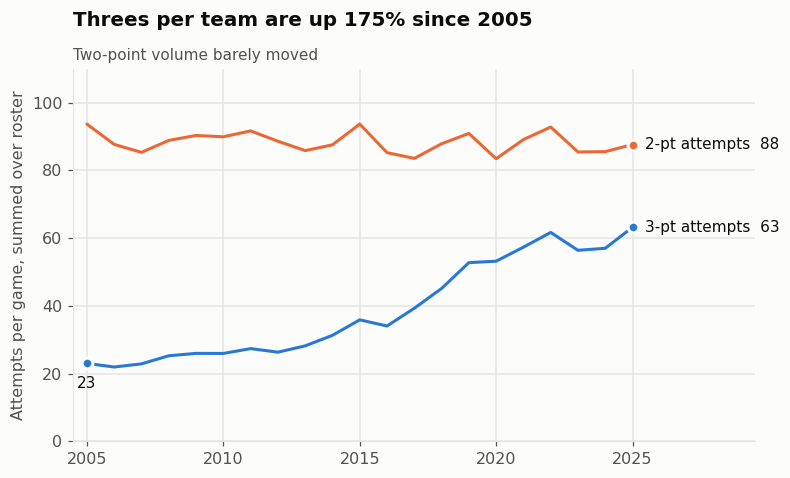

In [5]:
attempts = eda.attempts_per_team(players)
fig = plots.attempts(attempts); plots.save(fig, "three_point_volume")
share = eda.three_point_share(players)
print(f"3PA per team: {attempts['3PA'].iloc[0]:.0f} → {attempts['3PA'].iloc[-1]:.0f} "
      f"(+{attempts['3PA'].iloc[-1] / attempts['3PA'].iloc[0] - 1:.0%}; report: +171%)")
print("3PA share of shots (%):", (share.loc[[2005, 2010, 2015, 2020, 2025]] * 100).round().astype(int).to_dict())

**Points per attempt.** The report multiplied the *average of players' shooting percentages* by the shot value.
A player who never shoots threes enters that average as a 0% shooter, which drags 3P% down and made twos look
better every season. Dividing a team's made shots by its attempts instead:

,2PT,3PT,2PT (report method),3PT (report method),three worth more
Season,,,,,
2005,0.925,1.043,0.886,0.653,True
2006,0.944,1.052,0.901,0.644,True
2007,0.956,1.052,0.901,0.660,True
2008,0.955,1.053,0.912,0.659,True
2009,0.957,1.077,0.917,0.722,True
2010,0.974,1.042,0.937,0.681,True
2011,0.961,1.053,0.918,0.697,True
2012,0.945,1.016,0.917,0.676,True
2013,0.951,1.048,0.905,0.713,True


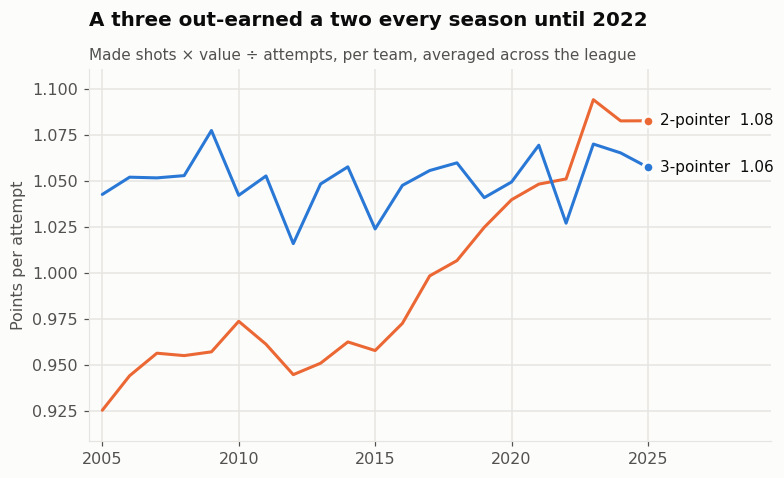

In [6]:
ep = eda.expected_points(players, weighted=True)
fig = plots.expected_points(ep); plots.save(fig, "expected_points")
comparison = ep.join(eda.expected_points(report_players), rsuffix=" (report method)")
comparison["three worth more"] = comparison["3PT"] > comparison["2PT"]
comparison.round(3)

In [7]:
team_3p = eda.three_share_vs_wins(players, standings)
r = team_3p["W%"].corr(team_3p["3P_share"])
print(f"Correlation between a team's 3PA share and its win %: r = {r:.3f} (n = {len(team_3p)})")

Correlation between a team's 3PA share and its win %: r = 0.119 (n = 630)


Threes nearly tripled, and for most of the period that was simply rational: from 2005 to 2021 a three returned
**more** points per attempt than a two. Since 2022 twos have edged ahead again (better rim finishing, and defenses
running shooters off the line). Still, a team's three-point share barely tracks its record (r ≈ 0.12): *how often* a
team shoots threes says little about how good it is. This reverses the report's conclusion that twos were worth more throughout.

## 3 · Offense or defense?
Composite 0-100 ratings: offense = points, assists, offensive rebounds, free throws, TS%; defense = steals, blocks, defensive rebounds (each min-max scaled within the season).

r(offense, W%) = 0.546 · r(defense, W%) = 0.576


,Season,Team,Offense,Defense,W%
339,2016,GSW,72.710,79.840,0.890
620,2025,OKC,55.698,77.697,0.829
66,2007,DAL,68.869,76.937,0.817
309,2015,GSW,73.217,90.672,0.817
356,2016,SAS,35.592,50.776,0.817
369,2017,GSW,62.253,80.731,0.817
91,2008,BOS,68.098,65.611,0.805
125,2009,CLE,44.009,48.421,0.805
255,2013,MIA,79.495,79.940,0.805
133,2009,LAL,81.948,80.840,0.793


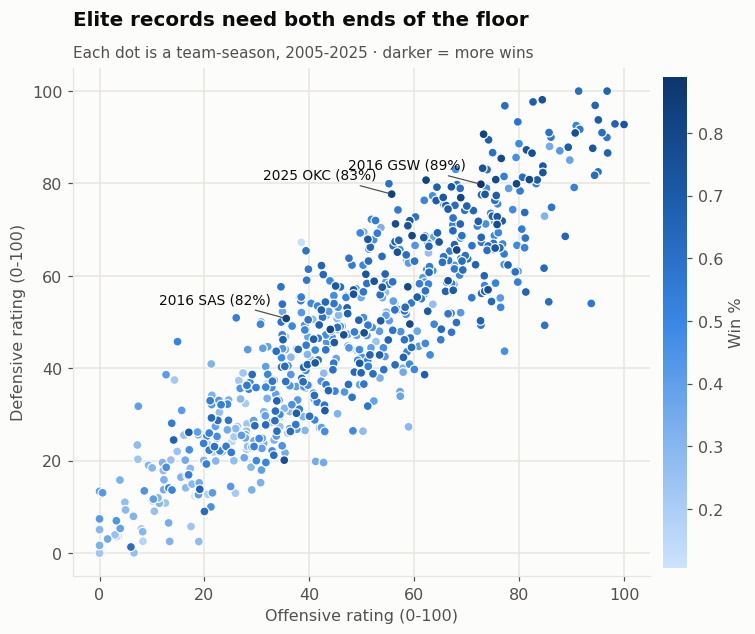

In [8]:
ratings = eda.offense_defense_ratings(players, standings)
fig = plots.offense_defense(ratings); plots.save(fig, "offense_defense")
print(f"r(offense, W%) = {ratings.Offense.corr(ratings['W%']):.3f} · "
      f"r(defense, W%) = {ratings.Defense.corr(ratings['W%']):.3f}")
ratings.nlargest(10, "W%").round(3)

Both indices correlate with winning about equally (defense slightly more; the report had the two numbers swapped). The best records sit in the top-right. A few defense-first teams (2016 Spurs, 2025 Thunder) got there with a merely average offense.

## 4 · Award-winning talent

,corrected,report
Roster,,
No award winner,0.438,0.437
All-NBA,0.579,0.588
DPOY,0.644,0.625
MVP,0.694,0.693


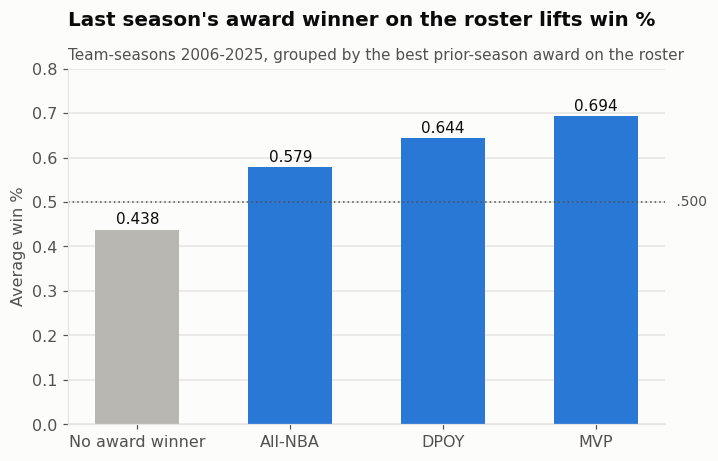

In [9]:
buckets = eda.award_win_pct(players, standings)
fig = plots.awards(buckets); plots.save(fig, "awards")
pd.DataFrame({"corrected": buckets, "report": eda.award_win_pct(report_players, standings)}).round(3)

Teams with last season's MVP averaged a .694 win %, versus .438 for teams with no prior-season award winner. That gap is why lagged awards are model features (notebook 2).